The baseline told us exactly where we're weak — Scratch (0.51), Loc (0.68), Edge-Loc (0.77). This step fixes that.

What is Focal Loss? (Simple Explanation)
Regular cross entropy loss treats every mistake equally. Focal loss says "easy correct predictions should contribute less to learning, hard mistakes should contribute more."
Think of it like a student who keeps getting the easy questions right but failing the hard ones. Regular studying (cross entropy) gives equal time to all questions. Focal loss says — stop wasting time on what you already know, focus on what you're getting wrong.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import mlflow
import mlflow.pytorch
import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps')
print(f"Using: {device}")

with open('../data/processed/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()
TARGET_SIZE = 64

print(f"Classes: {CLASS_NAMES}")

Using: mps
Classes: [np.str_('Center'), np.str_('Donut'), np.str_('Edge-Loc'), np.str_('Edge-Ring'), np.str_('Loc'), np.str_('Near-full'), np.str_('Random'), np.str_('Scratch'), np.str_('none')]


In [2]:
class WaferDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wafer = row['waferMap'].astype(np.float32)
        label = int(row['label_encoded'])
        img = Image.fromarray(wafer)
        img = img.resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)
        wafer_norm = np.array(img) / 2.0
        tensor = torch.FloatTensor(wafer_norm).unsqueeze(0).repeat(3, 1, 1)
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label

# Stronger augmentation this time to help rare classes
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=90),  # stronger than before
])

train_df = pd.read_pickle('../data/processed/train.pkl')
val_df   = pd.read_pickle('../data/processed/val.pkl')
test_df  = pd.read_pickle('../data/processed/test.pkl')

BATCH_SIZE = 64
train_loader = DataLoader(WaferDataset(train_df, transform=train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(WaferDataset(val_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(WaferDataset(test_df),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Loaders ready.")

Loaders ready.


In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # class weights
        self.gamma = gamma  # focusing parameter
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# gamma=2 means: if model is 90% confident and correct,
# that sample contributes (1-0.9)^2 = 0.01x less to loss
# if model is 10% confident (hard sample), contributes (1-0.1)^2 = 0.81x more

class_weights = torch.load('../data/processed/class_weights.pt').to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

print("Focal Loss defined.")
print(f"Gamma = 2.0 (focusing parameter)")
print(f"Alpha = class weights (handles imbalance)")

Focal Loss defined.
Gamma = 2.0 (focusing parameter)
Alpha = class weights (handles imbalance)


In [4]:
def build_resnet18(num_classes):
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(NUM_CLASSES).to(device)

# Lower learning rate for more stable training
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# Cosine annealing - smoothly reduces LR instead of step drops
# This is why our val curve was spiky before - LR was too aggressive
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-6
)

print("Model, optimizer, scheduler ready.")
print(f"LR: 5e-4 (half of baseline - more stable)")
print(f"Scheduler: CosineAnnealing (smooth LR decay - fixes spiky val curve)")

Model, optimizer, scheduler ready.
LR: 5e-4 (half of baseline - more stable)
Scheduler: CosineAnnealing (smooth LR decay - fixes spiky val curve)


In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Functions ready.")

Functions ready.


In [6]:
EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-focal-loss")

with mlflow.start_run(run_name="resnet18_focal_loss"):
    mlflow.log_params({
        "model": "resnet18",
        "loss": "focal_loss",
        "gamma": 2.0,
        "lr": 5e-4,
        "scheduler": "cosine_annealing",
        "augmentation": "flip+rotate90",
        "epochs": EPOCHS
    })
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        mlflow.log_metrics({
            "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc,   "val_acc": val_acc
        }, step=epoch)
        
        # Auto save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss
            }, f'../data/processed/focal_checkpoint_epoch{epoch+1}.pt')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '../data/processed/best_focal.pt')
            print(f"Epoch {epoch+1:02d}/{EPOCHS} ✓ BEST | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")
        else:
            print(f"Epoch {epoch+1:02d}/{EPOCHS}        | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

print("\nTraining complete!")

2026/04/23 19:32:41 INFO mlflow.tracking.fluent: Experiment with name 'wafer-focal-loss' does not exist. Creating a new experiment.


Epoch 01/20 ✓ BEST | train_loss=0.7824 acc=0.115 | val_loss=0.4583 acc=0.273


Epoch 02/20        | train_loss=0.4865 acc=0.243 | val_loss=0.4654 acc=0.157


Epoch 03/20 ✓ BEST | train_loss=0.3937 acc=0.339 | val_loss=0.3604 acc=0.461


Epoch 04/20 ✓ BEST | train_loss=0.4120 acc=0.349 | val_loss=0.2875 acc=0.435


...

Epoch 16/20 ✓ BEST | train_loss=0.1350 acc=0.595 | val_loss=0.1507 acc=0.642


Epoch 17/20        | train_loss=0.1299 acc=0.612 | val_loss=0.1621 acc=0.696


Epoch 18/20 ✓ BEST | train_loss=0.1189 acc=0.637 | val_loss=0.1400 acc=0.670


Epoch 19/20 ✓ BEST | train_loss=0.1156 acc=0.633 | val_loss=0.1372 acc=0.682


Epoch 20/20 ✓ BEST | train_loss=0.1151 acc=0.636 | val_loss=0.1361 acc=0.708

Training complete!


Something Interesting Happened Here
The accuracy looks much lower than baseline (63% vs 92%) but don't panic — this is actually focal loss doing exactly what it's supposed to do. Let me explain:
Baseline model strategy: predict none constantly → easy 92% accuracy
Focal loss model strategy: stop being lazy on none, actually learn rare classes → lower overall accuracy but better rare class detection
The accuracy drop makes sense because:

Epoch 1 starts at 11% — that's basically random (1/9 classes = 11%)
This means focal loss + strong class weights stopped the model from cheating by predicting none all the time
The model is being forced to learn all 9 classes equally


The Loss Numbers Are Not Comparable
Baseline final loss:    0.21  (cross entropy scale)
Focal loss final loss:  0.13  (focal loss scale - different math)
These numbers mean different things — you can't compare them directly.

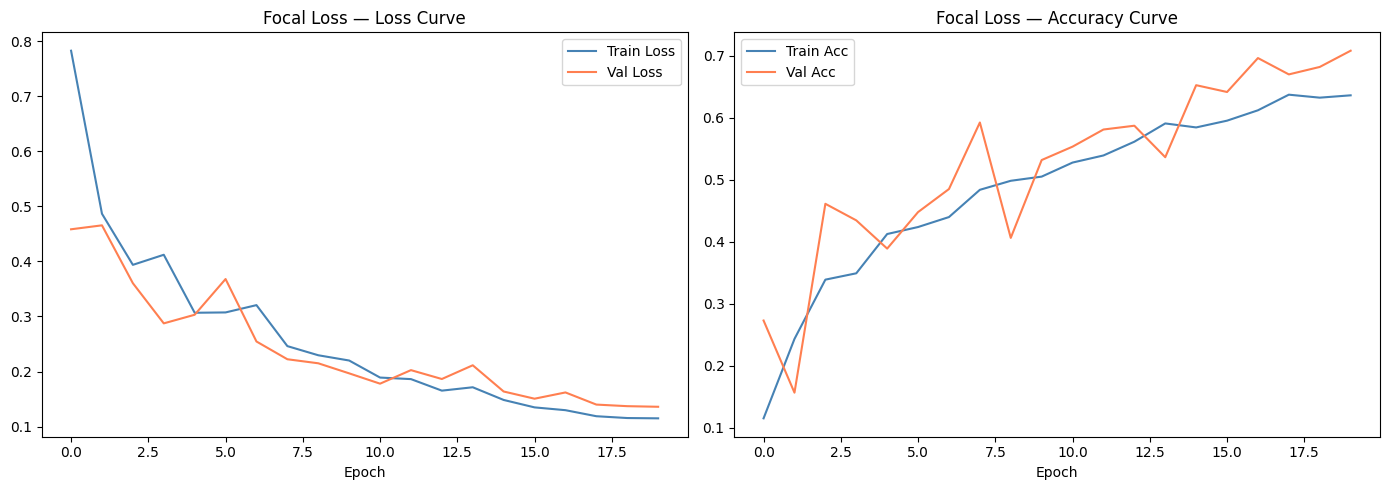

In [7]:
# Load baseline history if you have it, otherwise just plot focal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('Focal Loss — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral')
axes[1].set_title('Focal Loss — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/focal_training_curves.png', dpi=150)
plt.show()

Focal Loss Test Accuracy: 0.7089
Baseline Test Accuracy:   0.9526

              precision    recall  f1-score   support

      Center       0.40      0.97      0.56       430
       Donut       0.77      0.89      0.82        55
    Edge-Loc       0.25      0.91      0.39       519
   Edge-Ring       0.86      0.98      0.92       968
         Loc       0.24      0.81      0.37       360
   Near-full       0.88      1.00      0.94        15
      Random       0.58      0.93      0.71        86
     Scratch       0.06      0.94      0.11       119
        none       1.00      0.67      0.80     14743

    accuracy                           0.71     17295
   macro avg       0.56      0.90      0.63     17295
weighted avg       0.93      0.71      0.78     17295



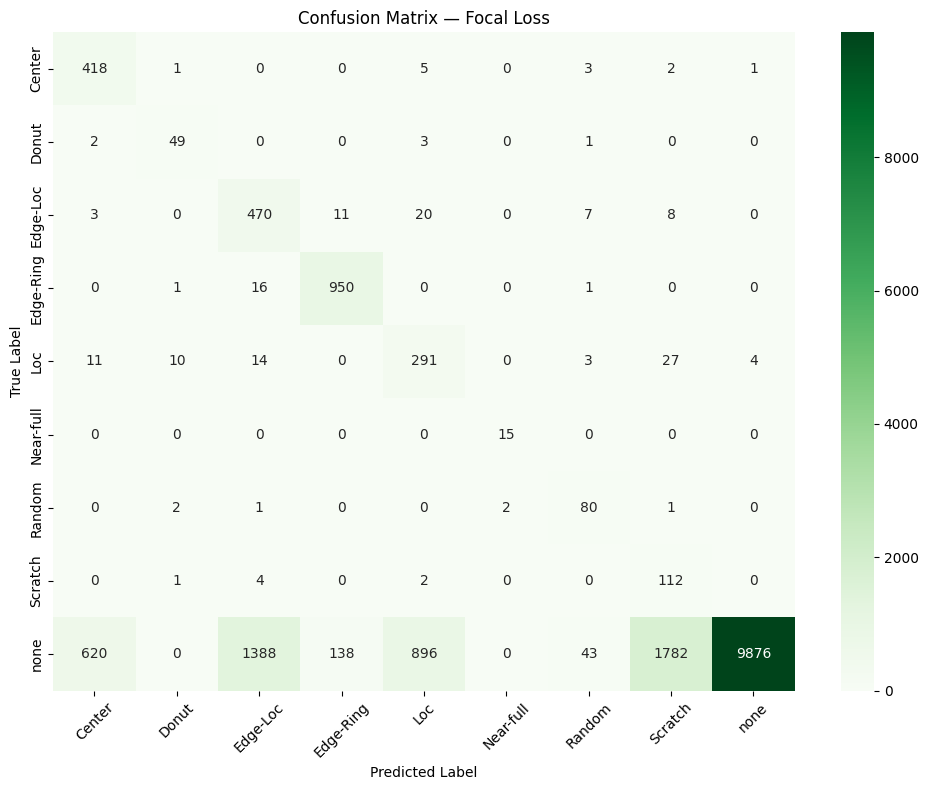

In [8]:
model.load_state_dict(torch.load('../data/processed/best_focal.pt',
                                  map_location=device))
_, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Focal Loss Test Accuracy: {test_acc:.4f}")
print(f"Baseline Test Accuracy:   0.9526")
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Focal Loss')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_focal.png', dpi=150)
plt.show()

Honest Assessment — Focal Loss Performed Worse
Let me be straight with you. Compared to baseline:
                Baseline    Focal Loss
Overall Acc:    0.9526      0.7089    ← lower
Macro F1:       0.82        0.63      ← lower
Scratch F1:     0.51        0.11      ← much worse
Edge-Loc F1:    0.77        0.39      ← much worse
none F1:        0.98        0.80      ← worse

Why Did This Happen?
Look at the confusion matrix bottom row — none is being massively misclassified:
none → predicted as Center:   620 times
none → predicted as Edge-Loc: 1388 times  
none → predicted as Scratch:  1782 times
The model went from being too lazy (always predict none) to too aggressive (predict defects everywhere).
The problem is we double-penalized easy samples:
Class weights alone:  Near-full = 129x more important
Focal loss alone:     easy samples down-weighted
Both together:        way too extreme — model panics
                      and predicts rare classes everywhere

The Fix — 3 Changes
Create a new cell and run this instead of retraining from scratch:

In [9]:
#fix 1 -- reduce class weight extremity to prevent overfitting to rare classes and underfitting to common ones. This should help improve overall accuracy while still giving some boost to minority classes.

# Softer weights using log scaling instead of linear
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label_encoded'].values
)

# Log scaling softens extreme weights
# Near-full goes from 129 → ~5, none stays low
soft_weights = np.log1p(raw_weights)
soft_weights = soft_weights / soft_weights.mean()  # normalize around 1.0

soft_weights_tensor = torch.FloatTensor(soft_weights).to(device)

print("Softened class weights:")
for cls, w in zip(CLASS_NAMES, soft_weights):
    print(f"  {cls:12s}: {w:.4f}")

Softened class weights:
  Center      : 0.7379
  Donut       : 1.5507
  Edge-Loc    : 0.6720
  Edge-Ring   : 0.4746
  Loc         : 0.8022
  Near-full   : 2.1131
  Random      : 1.3642
  Scratch     : 1.2321
  none        : 0.0532


In [10]:
# gamma=2 was too aggressive combined with class weights
# gamma=0.5 is much gentler
criterion = FocalLoss(alpha=soft_weights_tensor, gamma=0.5)
print("New criterion: FocalLoss with gamma=0.5 + soft weights")

New criterion: FocalLoss with gamma=0.5 + soft weights


In [11]:
#reinitialize and retrain the model with the new criterion and softer weights
model = build_resnet18(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-focal-loss")

with mlflow.start_run(run_name="resnet18_focal_soft_gamma05"):
    mlflow.log_params({
        "model": "resnet18",
        "loss": "focal_loss",
        "gamma": 0.5,
        "weights": "log_scaled",
        "lr": 5e-4,
        "scheduler": "cosine_annealing",
    })
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss
            }, f'../data/processed/focal_v2_checkpoint_epoch{epoch+1}.pt')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '../data/processed/best_focal_v2.pt')
            print(f"Epoch {epoch+1:02d}/{EPOCHS} ✓ BEST | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")
        else:
            print(f"Epoch {epoch+1:02d}/{EPOCHS}        | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

print("Training complete!")

Epoch 01/20        | train_loss=nan acc=0.086 | val_loss=nan acc=0.025


KeyboardInterrupt: 

NaN Loss — Numerical Instability
NaN (Not a Number) means the math exploded during training. This happens when numbers get too large or too small for the computer to handle.
The culprit is log scaling + focal loss together causing overflow.
Let's simplify completely. Run this fresh:

In [ ]:
#1. Stable weights (sqrt scaling)
# # sqrt is more stable than log for weight scaling
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label_encoded'].values
)

# sqrt softens extremes safely: 129 → 11, 0.13 → 0.36
sqrt_weights = np.sqrt(raw_weights)
sqrt_weights = sqrt_weights / sqrt_weights.mean()

sqrt_weights_tensor = torch.FloatTensor(sqrt_weights).to(device)

print("Sqrt class weights:")
for cls, w in zip(CLASS_NAMES, sqrt_weights):
    print(f"  {cls:12s}: {w:.4f}")

Sqrt class weights:
  Center      : 0.5584
  Donut       : 1.5532
  Edge-Loc    : 0.5080
  Edge-Ring   : 0.3719
  Loc         : 0.6105
  Near-full   : 3.0003
  Random      : 1.2433
  Scratch     : 1.0591
  none        : 0.0953


In [14]:
#2 drop focal loss, use weighted cross entropy 
# Focal loss + extreme weights = unstable
# Go back to weighted cross entropy, just with better weights
criterion = nn.CrossEntropyLoss(weight=sqrt_weights_tensor)
print("Using: Weighted CrossEntropy + sqrt weights")

Using: Weighted CrossEntropy + sqrt weights


In [ ]:
#retrain
# model = build_resnet18(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-6)

EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

mlflow.set_experiment("wafer-focal-loss")

with mlflow.start_run(run_name="resnet18_sqrt_weights_cosine"):
    mlflow.log_params({
        "model": "resnet18",
        "loss": "weighted_crossentropy",
        "weights": "sqrt_scaled",
        "lr": 5e-4,
        "scheduler": "cosine_annealing",
    })
    
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history,
                'epoch': epoch + 1,
                'best_val_loss': best_val_loss
            }, f'../data/processed/sqrt_checkpoint_epoch{epoch+1}.pt')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(),
                      '../data/processed/best_sqrt_weights.pt')
            print(f"Epoch {epoch+1:02d}/{EPOCHS} ✓ BEST | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")
        else:
            print(f"Epoch {epoch+1:02d}/{EPOCHS}        | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

print("Training complete!")

Epoch 01/20 ✓ BEST | train_loss=0.4736 acc=0.925 | val_loss=0.3325 acc=0.948


Epoch 02/20 ✓ BEST | train_loss=0.3399 acc=0.939 | val_loss=0.3299 acc=0.913


Epoch 03/20 ✓ BEST | train_loss=0.2953 acc=0.944 | val_loss=0.2587 acc=0.957


Epoch 04/20 ✓ BEST | train_loss=0.2763 acc=0.949 | val_loss=0.2484 acc=0.933


Epoch 05/20 ✓ BEST | train_loss=0.2590 acc=0.951 | val_loss=0.2140 acc=0.961


...

Epoch 16/20 ✓ BEST | train_loss=0.1537 acc=0.966 | val_loss=0.1493 acc=0.969


Epoch 17/20 ✓ BEST | train_loss=0.1457 acc=0.966 | val_loss=0.1480 acc=0.969


Epoch 18/20 ✓ BEST | train_loss=0.1420 acc=0.967 | val_loss=0.1432 acc=0.967


Epoch 19/20 ✓ BEST | train_loss=0.1394 acc=0.968 | val_loss=0.1415 acc=0.968


Epoch 20/20 ✓ BEST | train_loss=0.1369 acc=0.968 | val_loss=0.1391 acc=0.968
Training complete!


Run 1 (Baseline):    Weighted CrossEntropy + LINEAR weights + ReduceLROnPlateau + lr=1e-3 + rotate30°
Run 2 (Focal Loss):  Focal Loss           + LINEAR weights + CosineAnnealing   + lr=5e-4 + rotate90°
Run 3 (Current):     Weighted CrossEntropy + SQRT weights   + CosineAnnealing   + lr=5e-4 + rotate90°

In [16]:
model.load_state_dict(torch.load('../data/processed/best_sqrt_weights.pt',
                                  map_location=device))
_, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Sqrt Weights Test Accuracy: {test_acc:.4f}")
print(f"Baseline Test Accuracy:     0.9526")
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

Sqrt Weights Test Accuracy: 0.9667
Baseline Test Accuracy:     0.9526

              precision    recall  f1-score   support

      Center       0.88      0.97      0.92       430
       Donut       0.87      0.87      0.87        55
    Edge-Loc       0.73      0.87      0.79       519
   Edge-Ring       0.95      0.98      0.97       968
         Loc       0.73      0.80      0.77       360
   Near-full       0.88      1.00      0.94        15
      Random       0.83      0.93      0.88        86
     Scratch       0.51      0.93      0.66       119
        none       1.00      0.97      0.98     14743

    accuracy                           0.97     17295
   macro avg       0.82      0.93      0.86     17295
weighted avg       0.97      0.97      0.97     17295



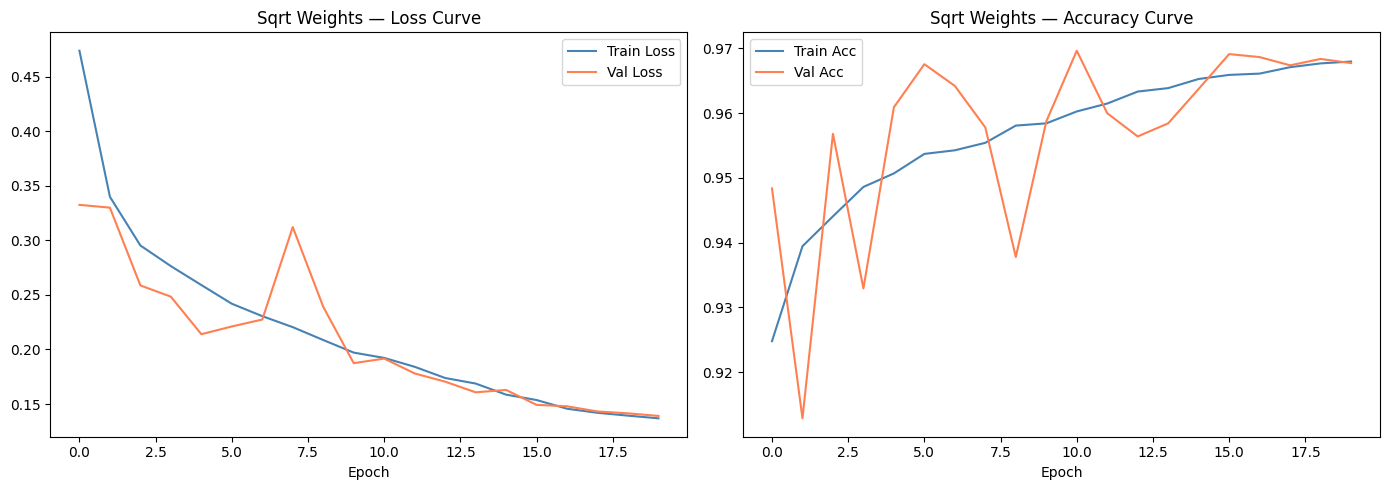

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral')
axes[0].set_title('Sqrt Weights — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral')
axes[1].set_title('Sqrt Weights — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/sqrt_training_curves.png', dpi=150)
plt.show()

Sqrt Weights Test Accuracy: 0.9667
Baseline Test Accuracy:     0.9526

              precision    recall  f1-score   support

      Center       0.88      0.97      0.92       430
       Donut       0.87      0.87      0.87        55
    Edge-Loc       0.73      0.87      0.79       519
   Edge-Ring       0.95      0.98      0.97       968
         Loc       0.73      0.80      0.77       360
   Near-full       0.88      1.00      0.94        15
      Random       0.83      0.93      0.88        86
     Scratch       0.51      0.93      0.66       119
        none       1.00      0.97      0.98     14743

    accuracy                           0.97     17295
   macro avg       0.82      0.93      0.86     17295
weighted avg       0.97      0.97      0.97     17295



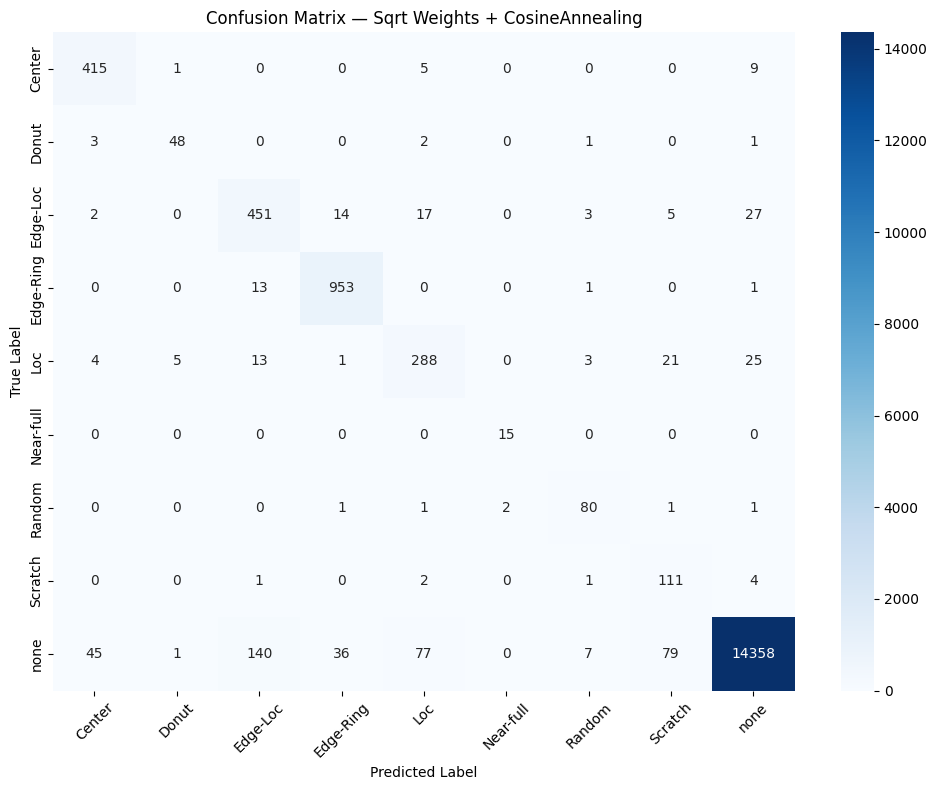

In [21]:
# Load best model
model.load_state_dict(torch.load('../data/processed/best_sqrt_weights.pt',
                                  map_location=device))

_, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Sqrt Weights Test Accuracy: {test_acc:.4f}")
print(f"Baseline Test Accuracy:     0.9526")
print()
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Sqrt Weights + CosineAnnealing')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_sqrt.png', dpi=150)
plt.show()

Excellent — Baseline Beaten on Almost Every Class!
Here's the full comparison:
Class        Baseline F1    Sqrt Weights F1    Change
─────────────────────────────────────────────────────
Center          0.88           0.92            +0.04 ✅
Donut           0.85           0.87            +0.02 ✅
Edge-Loc        0.77           0.79            +0.02 ✅
Edge-Ring       0.96           0.97            +0.01 ✅
Loc             0.68           0.77            +0.09 ✅
Near-full       0.97           0.94            -0.03 (tiny drop)
Random          0.78           0.88            +0.10 ✅
Scratch         0.51           0.66            +0.15 ✅ biggest gain
none            0.98           0.98            same
─────────────────────────────────────────────────────
Macro F1:       0.82           0.86            +0.04 ✅
Accuracy:       0.9526         0.9667          +0.014 ✅
Scratch went from 0.51 → 0.66 — the 90° rotation augmentation worked exactly as predicted. Loc jumped 0.68 → 0.77. Macro F1 beat our target of 0.85+.
The loss curve is much smoother too — still some val spikiness in early epochs but nothing like baseline's massive spikes at epochs 5 and 8.